<a href="https://colab.research.google.com/github/spirosChv/neuro208/blob/main/practicals/practical3_part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulating dendrites - Part 1

In [1]:
!pip install neuron --quiet

## Compile ion channel models (`.mod` files)

In [2]:
# @title Create the mod file
# @markdown Execute this cell.
with open("Traub.mod", "w") as file:
  file.write("""

    COMMENT
    All the channels are taken from same good old classic articles.
    The arrengment was done after:
    Kang, S., Kitano, K., and Fukai, T. (2004). 
      Self-organized two-state membrane potential 
      transitions in a network of realistically modeled 
      cortical neurons. Neural Netw 17, 307-312.
    
    Whenever available I used the same parameters they used,
    except in n gate:
      n' = phi*(ninf-n)/ntau
    
    Kang used phi = 12
    I used phi = 1
    
    Written by Albert Gidon & Leora Menhaim (2004).
    ENDCOMMENT

    UNITS {
        (mA) = (milliamp)
        (mV) = (millivolt)
        (S) = (siemens)		
    }

    NEURON {
      SUFFIX traub
      NONSPECIFIC_CURRENT i
      RANGE iL,iNa,iK
      RANGE eL, eNa, eK
      RANGE gLbar, gNabar, gKbar
      RANGE v_shft
    }

    PARAMETER {
        gNabar = .03 (S/cm2)	:Traub et. al. 1991
        gKbar = .015 (S/cm2) 	:Traub et. al. 1991
        gLbar = 0.00014 (S/cm2) :Siu Kang - by email.
        eL = -62.0 (mV) :Siu Kang - by email.
        eK = -80 (mV)	:Siu Kang - by email.
        eNa = 90 (mV)	:Leora
        totG = 0
        v_shft = 49.2 : shift to apply to all curves
    }
    
    STATE {
        m h n a b
    }
    
    ASSIGNED {
        v (mV)
        i (mA/cm2)
        cm (uF)
        iL (mA/cm2)
        iNa (mA/cm2)
        iK (mA/cm2)
        gNa (S/cm2)
        gK (S/cm2)
        minf hinf ninf 
        mtau (ms) htau (ms) ntau (ms) 
    }


    BREAKPOINT {
        SOLVE states METHOD cnexp 
        :-------------------------
        :Traub et. al. 1991
        gNa = gNabar*h*m*m
        iNa = gNa*(v - eNa)
        gK = gKbar*n : - Traub et. al. 1991
        iK = gK*(v - eK)
        :-------------------------
        iL = gLbar*(v - eL) 
        i = iL + iK + iNa
        :to calculate the input resistance get the sum of
        :	all the conductance.
        totG = gNa + gK + gLbar      
    }
    
    INITIAL {
        rates(v)
        m = minf
        h = hinf
        n = ninf
    }

    ? states
    DERIVATIVE states {  
        rates(v)
        :Traub Spiking channels
        m' = (minf-m)/mtau
        h' = (hinf-h)/htau
        n' = 2*(ninf-n)/ntau :phi=12 from Kang et. al. 2004
    }

    ? rates
    DEFINE Q10 3
    PROCEDURE rates(v(mV)) {  
      :Computes rate and other constants at current v.
      :Call once from HOC to initialize inf at resting v.
      LOCAL  alpha, beta, sum, vt, Q
      TABLE 	mtau,ntau,htau,minf,ninf,hinf
      FROM -100 TO 70 WITH 1000
      : see Resources/The unreliable Q10.htm for details
      : remember that not only Q10 is temprature dependent 
      : and just astimated here, but also the calculation of
      : Q is itself acurate only in about 10% in this range of
      : temperatures. the transformation formulation is:
      : Q = Q10^(( new(degC) - from_original_experiment(degC) )/ 10)
      
      :--------------------------------------------------------
      
      : This part was taken **directly** from:
      : Traub, R. D., Wong, R. K., Miles, R., and Michelson, H. (1991). 
      :	A model of a CA3 hippocampal pyramidal neuron incorporating 
      :	voltage-clamp data on intrinsic conductances. 
      :	J Neurophysiol 66, 635-650.
      :	Experiments were done in >=32degC for m,h
      : Traub et al uses their -60mV as 0mV thus here is the shift
      vt = v + v_shft :49.2
      Q = Q10^((35 - 32)/ 10)
      :"m" sodium activation system
      if(vt == 13.1){alpha = 0.32*4}
      else{alpha = 0.32*(13.1 - vt)/(exp((13.1 - vt)/4) - 1)}
      if(vt == 40.1){beta = 0.28*5}
      else{beta = 0.28*(vt - 40.1)/(exp((vt - 40.1)/5)-1)}
      sum = alpha + beta
      mtau = 1/sum
      mtau = mtau/Q
      minf = alpha/sum

      :"h" sodium inactivation system
      alpha = 0.128*exp((17 - vt)/18)
      beta = 4/(1 + exp((40 - vt)/5))
      sum = alpha + beta
      htau = 1/sum
      htau = htau/Q
      hinf = alpha/sum

      :"n" potassium activation system
      if(vt == 35.1){ alpha = 0.016*5 }
      else{alpha =0.016*(35.1 - vt)/(exp((35.1 - vt)/5) - 1)}
      beta = 0.25*exp((20 - vt)/40)
      sum = alpha + beta
      ntau = 1/sum
      ntau = ntau/Q
      ninf = alpha/sum
    }
  """)

In [3]:
!rm -rf x86_64/
!nrnivmodl

/content
Mod files: "./Traub.mod"

Creating x86_64 directory for .o files.

COBJS=''
 -> NMODL ../Traub.mod
 -> Compiling mod_func.cpp
Translating Traub.mod into /content/x86_64/Traub.c
Thread Safe
 -> Compiling Traub.c
 => LINKING shared library ./libnrnmech.so
 => LINKING executable ./special LDFLAGS are:    -pthread
Successfully created x86_64/special


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from neuron import h
h.load_file("stdrun.hoc")

1.0

In [5]:
# @title Make nicer plots -- Execute this cell
def mystyle():
  """
  Create custom plotting style.

  Returns
  -------
  my_style : dict
      Dictionary with matplotlib parameters.

  """
  # color pallette
  style = {
      # Use LaTeX to write all text
      "text.usetex": False,
      "font.family": "DejaVu Sans",
      "font.weight": "bold",
      # Use 16pt font in plots, to match 16pt font in document
      "axes.labelsize": 16,
      "axes.titlesize": 20,
      "font.size": 16,
      # Make the legend/label fonts a little smaller
      "legend.fontsize": 14,
      "xtick.labelsize": 14,
      "ytick.labelsize": 14,
      "axes.linewidth": 2.5,
      "lines.markersize": 10.0,
      "lines.linewidth": 2.5,
      "xtick.major.width": 2.2,
      "ytick.major.width": 2.2,
      "axes.labelweight": "bold",
      "axes.spines.right": False,
      "axes.spines.top": False
  }

  return style


plt.style.use("seaborn-colorblind")
plt.rcParams.update(mystyle())

## How inputs propagate to the soma and how inputs interact.
### In this exercise we will see how inputs attenuate towards the soma. Also we will see how inputs integrate in a dendritic branch. 

In [6]:
# Simulation parameters	
tstop = 100  # ms
h.dt = 0.1  # ms
vinit = -68.5  # mV

### Create a soma and two dendrites, define their anatomical and biophysical properties and connect them.

In [7]:
soma = h.Section(name='soma')
dend0, dend1 = [h.Section(name=n) for n in ['dend0', 'dend1']]

# Define properties of soma
soma.diam = 20  # um
soma.L = 200  # um
soma.Ra = 100  # Axial resistance in Ohm * cm
soma.cm = 1  # specific membrane capacitance, capacitance per unit of membrane, uF/cm^2   
soma.nseg = 1  # number of segments (actual compartments)	

# Insert the hh channels (inluding leak)
soma.insert('hh')
for seg in soma: 
  seg.hh.gnabar = 0.12  # Sodium conductance in S/cm2
  seg.hh.gkbar = 0.036  # Potassium conductance in S/cm2
  seg.hh.gl = 0.0003  # Leak conductance in S/cm2
  seg.hh.el = -65  # Reversal potential in mV

# Define properties of dend0
dend0.diam = 5
dend0.L = 500
dend0.nseg = 11
dend0.cm = 1
dend0.Ra = 100

# Insert passive (leak) channels
dend0.insert('pas')      
for seg in dend0:
  seg.pas.e = -65  # leak reversal potential in mV
  seg.pas.g = 0.0003  # leak maximal conductance in S/cm2
	
# Define properties of dend1
dend1.diam = 3
dend1.L = 200
dend1.nseg = 13
dend1.cm = 1
dend1.Ra = 100

# Insert passive (leak) channels
dend1.insert('pas')     
for seg in dend0:
  seg.pas.e = -65  # leak reversal potential in mV
  seg.pas.g = 0.0003  # leak maximal conductance in S/cm2

# Connect the 0 point of dendrite 0 to the zero point of the soma
dend0.connect(soma(0), 0)
dend1.connect(dend0(1), 0)

dend1

### Synaptic Stimulation

In [8]:
# Place the synapse to the middle (0.5) of the soma, ...
syn = h.ExpSyn(dend1(0.5))
syn.e = 0  # Reverse potential of the synapse (mV)


#...create an artificial spike (an "event" to be delivered to the synapse)...
ns = h.NetStim(0.5)
ns.start = 50      
ns.number = 1  

#... and connect the event to the synapse.
nc = h.NetCon(ns, syn)
nc.delay = 2
nc.weight[0] = 0.008*1

### Example simulation
### Calculate and print in terminal the depolarization at the soma and at the middle part of the distal dendrite (`dend1`)

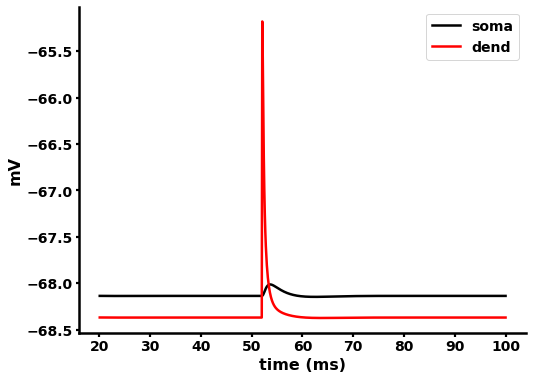

Somatic depolarization is 0.13 mV
Distal Dendritic depolarization is 3.2 mV


In [9]:
vsoma_vec = h.Vector().record(soma(0.5)._ref_v)  # Membrane potential vector
vdend1_vec = h.Vector().record(dend1(0.5)._ref_v)  # Membrane potential vector
t_vec = h.Vector().record(h._ref_t)  # Time stamp vector

# Run the simulation
h.finitialize(vinit)
h.continuerun(tstop)

# Remove the first 20ms to avoid artifacts
tremove = 20
vsoma_vec.remove(0, int(tremove/h.dt))
vdend1_vec.remove(0, int(tremove/h.dt))
t_vec.remove(0, int(tremove/h.dt))

plt.figure(figsize=(8, 6))
plt.plot(t_vec, vsoma_vec, color='black', label='soma')
plt.plot(t_vec, vdend1_vec, color='red', label='dend')
plt.xlabel('time (ms)')
plt.ylabel('mV')
plt.legend()
plt.show()

print (f'Somatic depolarization is {np.round(vsoma_vec.max()-vsoma_vec.min(), 2)} mV')
print (f'Distal Dendritic depolarization is {np.round(vdend1_vec.max()-vdend1_vec.min(),2)} mV')

### Task 1: How can you easily make this synapse inhibitory?

### Task 2: Move the synapse to the middle of `dend1` section.
### What do you expect for the amplitude and the duration of the EPSP seen at the dendrite and at the soma?

### Task 3: Insert 1 to 5 synapses like this one in the same location. In this case, this is equivalent to increasing the weight 1 to 5 times.
### What is the expected (arithmetic sum) versus actual (simulated output)?
### Is their relationship linear? 

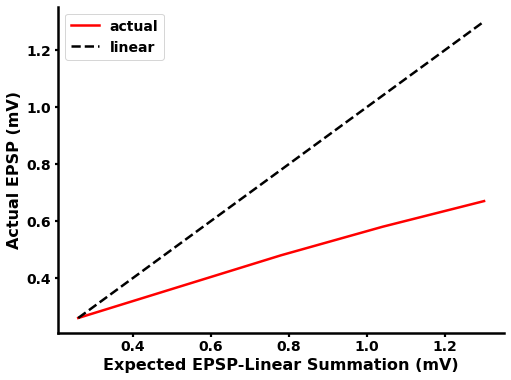

In [10]:
N = 5
actual_epsp = []
for i in range(N):
  vsoma_vec = h.Vector().record(soma(0.5)._ref_v)  # Membrane potential vector
  vdend1_vec = h.Vector().record(dend1(0.5)._ref_v)  # Membrane potential vector
  t_vec = h.Vector().record(h._ref_t)  # Time stamp vector
  
  nc = h.NetCon(ns, syn)
  nc.delay = 2
  nc.weight[0] = 0.008*(i+1)

  # reinitialize the simulator and run again
  h.finitialize(vinit)
  h.continuerun(tstop)
  
  # Remove the first 20ms to avoid artifacts
  tremove = 20
  vsoma_vec.remove(0, int(tremove/h.dt))
  t_vec.remove(0, int(tremove/h.dt))
  actual_epsp.append(np.round(vsoma_vec.max() - vsoma_vec.min(), 2))


expected_epsp = [actual_epsp[0]*i for i in range(1, N+1)]

plt.figure(figsize=(8, 6)) 
plt.plot(expected_epsp, actual_epsp, color='red', label='actual')
plt.plot(expected_epsp, expected_epsp, linestyle='dashed', color='black', label='linear')
plt.xlabel('Expected EPSP-Linear Summation (mV)')
plt.ylabel('Actual EPSP (mV)')
plt.legend()
plt.show()

## Excercise 1b

In [11]:
# Simulation parameters	
tstop = 100  # ms
h.dt = 0.1  # ms
vinit = -67.7  # initial membrane potential

In [12]:
# create five compartments using the command `h.Section()`
soma = h.Section(name='soma')
dend0, dend1, dend2, dend3 = [h.Section(name=n) for n in ['dend0', 'dend1', 'dend2', 'dend3']]

# Define properties of soma
soma.diam = 20  # um (micro-meter)
soma.L = 200  # um
soma.Ra = 100  # Axial resistance in Ohm * cm
soma.cm = 1  # specific membrane capacitance, capacitance per unit of membrane, uF/cm^2   
soma.nseg = 1  # number of segments (spatial grid)

# Insert Hodgkin-Huxley channels (including leak)
soma.insert('hh')
for seg in soma: 
  seg.hh.gnabar = 0.05  # Sodium conductance in S/cm2
  seg.hh.gkbar = 0.036  # Potassium conductance in S/cm2
  seg.hh.gl = 0.0003  # Leak conductance in S/cm2
  seg.hh.el = -65  # Reversal potential in mV

# Define properties of dend0
dend0.diam = 5
dend0.L = 500
dend0.nseg = 11
dend0.cm = 1
dend0.Ra = 100

dend0.insert('pas')  # Insert passive (leak) channels
for seg in dend0:
  seg.pas.e= -65
  seg.pas.g= 0.0003

# Define properties of dend1
dend1.diam = 3
dend1.L = 200
dend1.nseg = 13
dend1.cm = 1
dend1.Ra = 100

dend1.insert('pas')  # Insert passive (leak) channels
for seg in dend1:
  seg.pas.e = -65
  seg.pas.g = 0.0003
    
# Define properties of dend0
dend2.diam = 5
dend2.L = 500
dend2.nseg = 11
dend2.cm = 1
dend2.Ra = 100

dend2.insert('pas')  # Insert passive (leak) channels
for seg in dend2:
  seg.pas.e = -65
  seg.pas.g = 0.0003

# Define properties of dend1
dend3.diam = 3
dend3.L = 200
dend3.nseg = 13
dend3.cm = 1
dend3.Ra = 100

dend3.insert('pas')  # Insert passive (leak) channels
for seg in dend3:
  seg.pas.e= -65
  seg.pas.g= 0.0003
    
# Connect the compartments together
dend0.connect(soma(0), 0)  # Connect the 0 point of dendrite 0 to the zero point of the soma
dend1.connect(dend0(1), 0)  # etc...
dend2.connect(soma(1), 0)
dend3.connect(dend2(1), 0)

dend3

### Task 1: We will add one `h.ExpSyn` in the middle of `dend1` and one in the middle of `dend3`. 
### Activate (`weight*1`) each one of them and both of them. Is the response the linear sum?

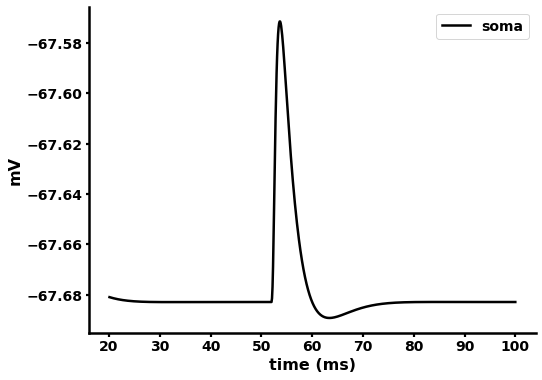


Somatic depolarization is 0.12 mV


In [13]:
#========== Synaptic stimulation.
# Place the synapse to the middle (0.5) of the soma, ...
syn0 = h.ExpSyn(dend1(0.5))
syn0.e = 0  # Reverse potential of the synapse (mV)

# Place the synapse to the middle (0.5) of the soma, ...
syn1 = h.ExpSyn(dend3(0.5))
syn1.e = 0

#========== ...create an artificial spike (an "event" to be delivered to the synapse)...
ns = h.NetStim(0.5)
ns.start = 50
ns.number = 1

#... and connect the event to the synapse.
nc0 = h.NetCon(ns, syn0)
nc0.delay = 2
nc0.weight[0] = 0.008*0

nc1 = h.NetCon(ns, syn1)
nc0.delay = 2
nc0.weight[0] = 0.008*1

# Calculate and print in terminal the depolarization at the soma and at the middle part of the distal dendrite (dend3)
vsoma_vec = h.Vector().record(soma(0.5)._ref_v)  # Membrane potential vector
t_vec = h.Vector().record(h._ref_t)  # Time stamp vector

# reinitialize the simulator and run again
h.finitialize(vinit)
h.continuerun(tstop)

# Remove the first 20ms to avoid artifacts
tremove = 20
vsoma_vec.remove(0, int(tremove/h.dt))
t_vec.remove(0, int(tremove/h.dt))

plt.figure(figsize=(8, 6))
plt.plot(t_vec, vsoma_vec, color='black', label='soma')
plt.legend()
plt.xlabel('time (ms)')
plt.ylabel('mV')
plt.show()

print(f'\nSomatic depolarization is {np.round(vsoma_vec.max() - vsoma_vec.min(), 2)} mV')

## Exercise 1c: Integrating inputs with active dendritic conductances
### In this exercise we will see how inputs can be amplified by active sodium conductances

In [14]:
# Simulation parameters
tstop = 100  # ms
h.dt = 0.1  # ms
vinit = -65  # initial membrane potential

### Create a soma and two dendrites, define their anatomical and biophysical properties and connect them.

In [15]:
# Create a soma and two dendrites and connect them.
soma = h.Section(name='soma')
dend0, dend1 = [h.Section(name=n) for n in ['dend0', 'dend1']]

# Define properties of soma
soma.diam = 20  # um
soma.L = 200  # um
soma.Ra = 100  # Axial resistance in Ohm * cm
soma.cm = 1  # specific membrane capacitance, capacitance per unit of membrane, uF/cm^2   
soma.nseg = 1  # number of segments (spatial grid)

# Insert only passive conductance into soma (in contrast to previous two exercises)    
soma.insert('pas')
for seg in soma:
  seg.pas.e = -65  # Reversal potential in mV
  seg.pas.g = 0.0003  # Leak conductance in S/cm2

# Define properties of dend0
dend0.diam = 5
dend0.L = 500
dend0.nseg = 11
dend0.cm = 1
dend0.Ra = 100

# Insert passive conductance into dend0
dend0.insert('pas')
for seg in dend0:
  seg.pas.e = -65
  seg.pas.g = 0.0003
    
# Define properties of dend1
dend1.diam = 3
dend1.L = 200
dend1.nseg = 13
dend1.cm = 1
dend1.Ra = 100

# dend1 will have active conductances! - Traub.mod contains HH-like Na and K conductances, as well as leak.
dend1.insert('traub')
for seg in dend1:
  seg.traub.gNabar = 0.1  # Sodium conductance in S/cm2
  seg.traub.gKbar = 0.045  # Potassium conductance in S/cm2
  seg.traub.gLbar = 0.0003  # Leak conductance in S/cm2
  seg.traub.eL = -65.  # Reversal potential for leak in mV
  seg.traub.eK = -70.  # Reversal potential for potassium in mV
  seg.traub.eNa = 90.  # Reversal potential for sodium in mV
  seg.traub.v_shft += 9.5  # Shifts the activation curve for sodium

# Connect the three compartments together
dend0.connect(soma(0), 0)  # 0 point of dendrite 0 to the zero point of the soma     
dend1.connect(dend0(1), 0)  # 0 point of dendrite 1 to the zero point of dendrite 0 

dend1

### Synaptic Stimulation

In [16]:
syn = h.ExpSyn(dend1(0.5)) # Place the synapse to the middle (0.5) of the soma
syn.e = 0  # Reverse potential of the synapse (mV)

# Create an artificial spike using h.NetStim() (an "event" to be delivered to the synapse)...
ns = h.NetStim(0.5)
ns.start = 50  # time when the spike arrives (in msec)     
ns.number = 1  # number of spikes (just one)

# ... and connect the event to the synapse.
nc = h.NetCon(ns, syn, -10, 2, 0.008*10)   # function arguments: NetCon(source, target, [threshold, delay, weight])

### Example simulation
#### Compare the depolarization at the soma with and without active conductances in the dendrites

In [ ]:
# record the necessary variables
vsoma_vec = h.Vector().record(soma(0.5)._ref_v)  # Membrane potential vector
vdend1_vec = h.Vector().record(dend1(0.5)._ref_v)  # Membrane potential vector
vdend0_vec = h.Vector().record(dend0(0.5)._ref_v)  # Membrane potential vector
iNa_vec = h.Vector().record(dend1(0.5).traub._ref_iNa)  # Sodium current vector
t_vec = h.Vector().record(h._ref_t)  # Time stamp vector

# --------------------------------------------------------------------------------------------------------------
# STEP 1: Run the simulation WITH active conductances as defined above
# --------------------------------------------------------------------------------------------------------------

# reinitialize the simulator and run again
h.finitialize(vinit)
h.frecord_init()
h.continuerun(tstop)

# Remove the first 20 msec of the plot (to make it look nice)
tremove = 20
vsoma_vec.remove(0, int(tremove/h.dt))
vdend1_vec.remove(0, int(tremove/h.dt))
vdend0_vec.remove(0, int(tremove/h.dt))
iNa_vec.remove(0, int(tremove/h.dt))
t_vec.remove(0, int(tremove/h.dt))

# Plot results
plt.figure(figsize=(8, 6))
plt.subplot(3, 1, 1)
plt.plot(t_vec, vsoma_vec, color='black')
plt.subplot(3, 1, 2)
plt.plot(t_vec, vdend1_vec, color='black')
plt.subplot(3, 1, 3)
plt.plot(t_vec, iNa_vec, color='black')

print(f'Active case: somatic depolarization is {round(vsoma_vec.max()-vsoma_vec.min(), 2)} mV')
print(f'Active case: distal dendritic depolarization is {round(vdend1_vec.max()-vdend1_vec.min(), 2)} mV')

# --------------------------------------------------------------------------------------------------------------
# STEP 2: Run the simulation WITHOUT active conductances by setting max conductances (gbar) to zero for Na and K
# --------------------------------------------------------------------------------------------------------------

